# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# 1. PROYECTO - ANÁLISIS EXPLORATORIO DE DATOS

## Dataset sintético de un generador axial trifásico PMSG 9b-8p

Este proyecto presenta un análisis exploratorio de datos (EDA)
utilizando un dataset sintético basado en el comportamiento
esperado de un generador síncrono de imanes permanentes (PMSG)
axial trifásico 9b-8p.

El dataset contiene variables eléctricas, mecánicas y térmicas,
además de ruido experimental y fallas simuladas.

# 2. IMPORTAR LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. CARGAR DATASET

In [ ]:
df = pd.read_csv("pmsg_axial_generator_dataset.csv")

df.head()

,rpm,gap_mm,temp_C,vibration_g,phase_fault,connection_noise,voltage_rms,current_A,power_W,efficiency,frequency_Hz
0,511.99,2.171,54.21,0.020,none,low,30.50,0.83,25.27,0.742,34.13
1,1145.79,2.016,50.63,0.058,none,low,67.18,1.58,106.06,0.745,76.39
2,905.19,2.039,47.51,0.097,none,low,51.74,0.97,50.41,0.747,60.35
3,758.52,1.322,62.43,0.111,none,high,46.03,0.88,40.39,0.707,50.57
4,271.62,2.224,36.91,0.168,none,low,16.14,0.18,2.86,0.763,18.11


# 4. INFORMACIÓN GENERAL

In [ ]:
print(df.shape)

df.info()

(3000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rpm               3000 non-null   float64
 1   gap_mm            2940 non-null   float64
 2   temp_C            2940 non-null   float64
 3   vibration_g       3000 non-null   float64
 4   phase_fault       3000 non-null   object 
 5   connection_noise  3000 non-null   object 
 6   voltage_rms       2940 non-null   float64
 7   current_A         3000 non-null   float64
 8   power_W           3000 non-null   float64
 9   efficiency        3000 non-null   float64
 10  frequency_Hz      3000 non-null   float64
dtypes: float64(9), object(2)
memory usage: 257.9+ KB


# 5. VALORES NULOS

In [ ]:
df.isnull().sum()

,0
rpm,0
gap_mm,60
temp_C,60
vibration_g,0
phase_fault,0
connection_noise,0
voltage_rms,60
current_A,0
power_W,0
efficiency,0


# 6. LIMPIEZA DE DATOS

In [ ]:
# Reemplazar valores nulos numéricos con la media

df['temp_C'].fillna(df['temp_C'].mean(), inplace=True)

df['gap_mm'].fillna(df['gap_mm'].mean(), inplace=True)

df['voltage_rms'].fillna(df['voltage_rms'].mean(), inplace=True)

/tmp/ipykernel_8581/4003574220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['temp_C'].fillna(df['temp_C'].mean(), inplace=True)
/tmp/ipykernel_8581/4003574220.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

# 7. VERIFICAR NULOS

In [ ]:
df.isnull().sum()

,0
rpm,0
gap_mm,0
temp_C,0
vibration_g,0
phase_fault,0
connection_noise,0
voltage_rms,0
current_A,0
power_W,0
efficiency,0


# 8. RESUMEN ESTADÍSTICO

In [ ]:
df.describe()

,rpm,gap_mm,temp_C,vibration_g,voltage_rms,current_A,power_W,efficiency,frequency_Hz
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,649.882510,1.794859,45.056129,0.080160,37.999527,0.836707,39.840970,0.744818,43.325590
std,320.822056,0.343466,14.663113,0.037434,19.525459,0.460298,34.845011,0.051729,21.388152
min,100.010000,1.000000,20.000000,0.010000,0.000000,0.050000,0.000000,0.539000,6.670000
25%,370.382500,1.558000,34.440000,0.054000,21.435000,0.467500,9.275000,0.720000,24.690000
50%,655.890000,1.794859,44.805000,0.080000,37.999527,0.820000,30.240000,0.753000,43.725000
75%,929.767500,2.024000,55.262500,0.106000,53.785000,1.200000,64.310000,0.780250,61.985000
max,1199.690000,3.000000,95.000000,0.215000,113.780000,2.030000,163.090000,0.828000,79.980000


# Observación:
# Se observan diferentes rangos de operación del generador.
# El voltaje y la potencia presentan variaciones debido
# a las condiciones simuladas de ruido y fallas.

# 9. HISTOGRAMA DE VOLTAJE

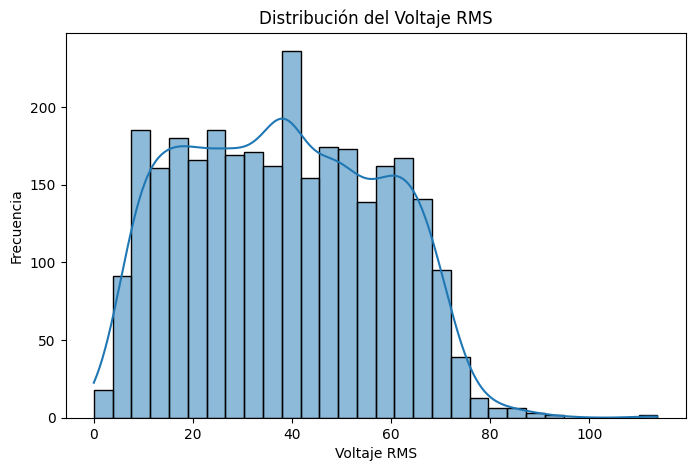

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['voltage_rms'], bins=30, kde=True)

plt.title("Distribución del Voltaje RMS")
plt.xlabel("Voltaje RMS")
plt.ylabel("Frecuencia")

plt.show()

# 10. HISTOGRAMA DE RPM

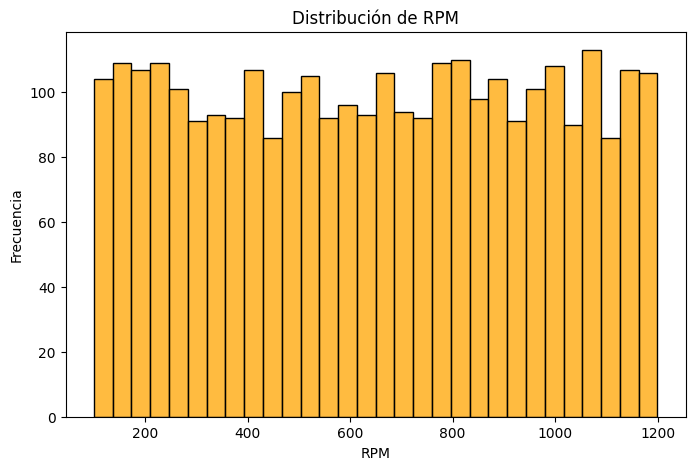

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['rpm'], bins=30, color='orange')

plt.title("Distribución de RPM")
plt.xlabel("RPM")
plt.ylabel("Frecuencia")

plt.show()

# 11. BOXPLOT PARA OUTLIERS

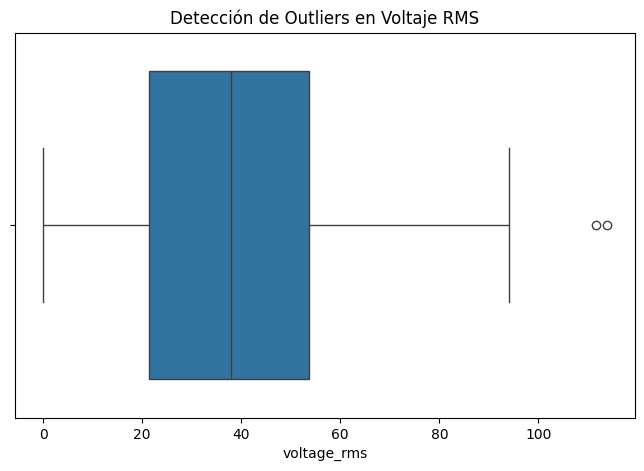

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['voltage_rms'])

plt.title("Detección de Outliers en Voltaje RMS")

plt.show()

# 12. MÉTODO IQR

In [ ]:
Q1 = df['voltage_rms'].quantile(0.25)
Q3 = df['voltage_rms'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['voltage_rms'] < limite_inferior) |
    (df['voltage_rms'] > limite_superior)
]

print("Cantidad de outliers:", outliers.shape[0])

Cantidad de outliers: 2


# 13. FILTRAR OUTLIERS

In [ ]:
df_filtrado = df[
    (df['voltage_rms'] >= limite_inferior) &
    (df['voltage_rms'] <= limite_superior)
]

print(df_filtrado.shape)

(2998, 11)


# 14. MATRIZ DE CORRELACIÓN

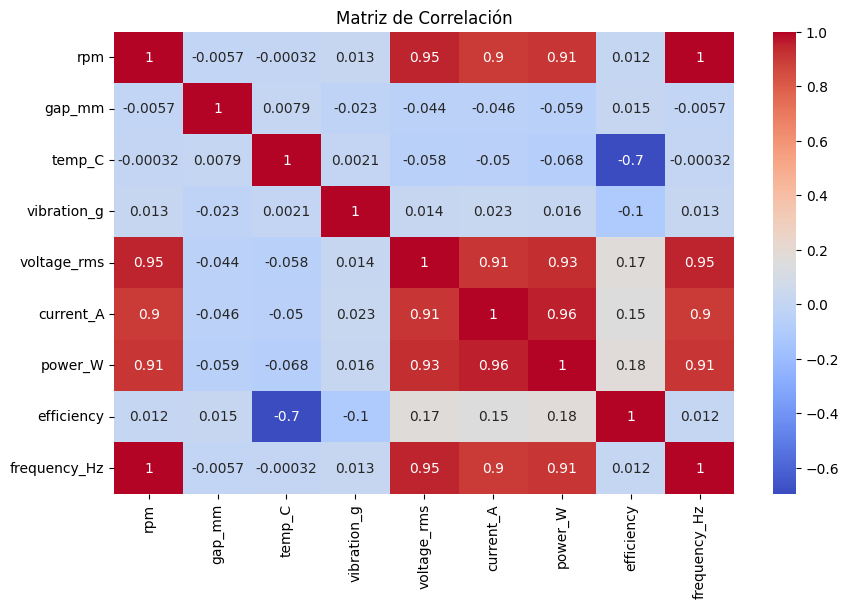

In [ ]:
correlacion = df_filtrado.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(correlacion,
            annot=True,
            cmap='coolwarm')

plt.title("Matriz de Correlación")

plt.show()

## Correlaciones

RPM ↔ Voltaje

Voltaje ↔ Potencia

muy fuertes.

# 15. REGRESIÓN LINEAL SIMPLE

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 16. VARIABLES

In [ ]:
X = df_filtrado[['rpm']]

y = df_filtrado['voltage_rms']

# 17. DIVISIÓN TRAIN/TEST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 18. ENTRENAR MODELO

In [ ]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

# 19. PREDICCIONES

In [ ]:
predicciones = modelo.predict(X_test)

r2 = r2_score(y_test, predicciones)

print("R2:", r2)

R2: 0.8963430191779098


# 20. GRÁFICA DE REGRESIÓN

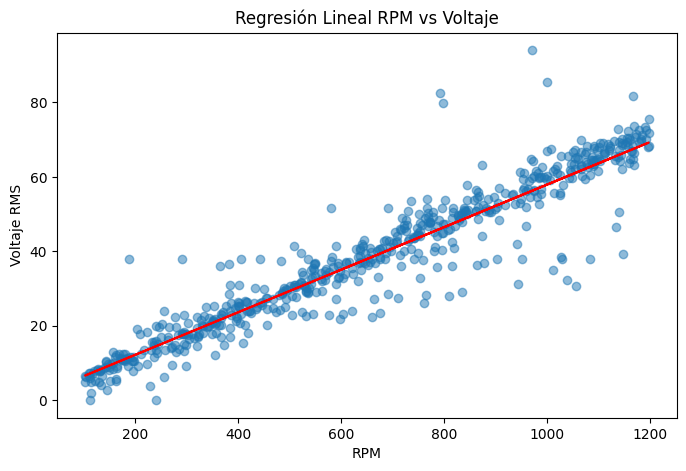

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, alpha=0.5)

plt.plot(X_test,
         predicciones,
         color='red')

plt.title("Regresión Lineal RPM vs Voltaje")
plt.xlabel("RPM")
plt.ylabel("Voltaje RMS")

plt.show()

# 21. CONCLUSIONES

In [ ]:
# Conclusiones

# 1. Existe una relación lineal positiva entre las RPM
#    y el voltaje RMS generado.

# 2. Las fallas y el ruido experimental generan
#    dispersión en los datos.

# 3. El método IQR permitió detectar valores atípicos.

# 4. La regresión lineal presentó un buen ajuste
#    para predecir el voltaje a partir de las RPM.

# 5. El análisis exploratorio ayudó a comprender
#    el comportamiento general del sistema.

# 22. REFERENCIAS

McKinney, W. (2022). Python for Data Analysis (3rd ed.). O’Reilly Media.

VanderPlas, J. (2016). Python Data Science Handbook. O’Reilly Media.

Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. Journal of Open Source Software, 6(60), 3021.

Thurner, L., Scheidler, A., Schäfer, F., Menke, J.-H., Dollichon, J., Meier, F., Meinecke, S., & Braun, M. (2018). pandapower — An Open Source Python Tool for Convenient Modeling, Analysis and Optimization of Electric Power Systems. IEEE Transactions on Power Systems.

Maffezzoni, P., Ferrario, A., & Codegoni, G. (2024). Equation-based and data-driven modeling: Open-source software current state and future directions. Computers & Chemical Engineering, 181, 108521.

Chapman, S. J. (2011). Electric Machinery Fundamentals (5th ed.). McGraw-Hill.

Fitzgerald, A. E., Kingsley, C., & Umans, S. D. (2003). Electric Machinery (6th ed.). McGraw-Hill.



# Figuras paper


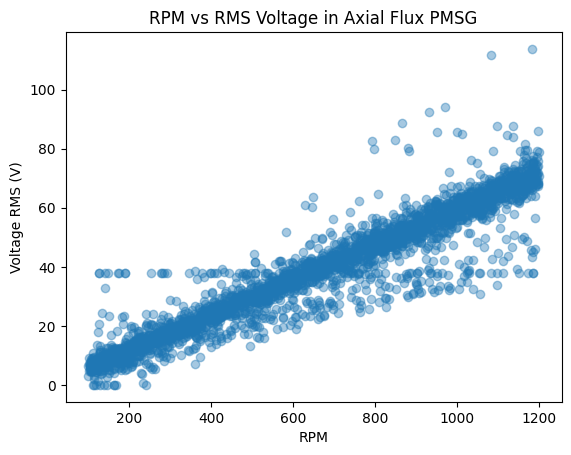

In [ ]:
sns.regplot(x=df["rpm"], y=df["voltage_rms"], scatter_kws={"alpha":0.4})
plt.title("RPM vs RMS Voltage in Axial Flux PMSG")
plt.xlabel("RPM")
plt.ylabel("Voltage RMS (V)")
plt.savefig("rpm_voltage.png", dpi=300)

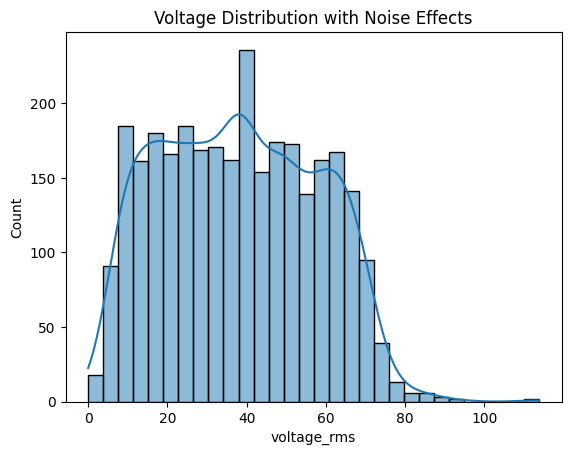

In [ ]:
sns.histplot(df["voltage_rms"], bins=30, kde=True)
plt.title("Voltage Distribution with Noise Effects")
plt.savefig("voltage_hist.png", dpi=300)

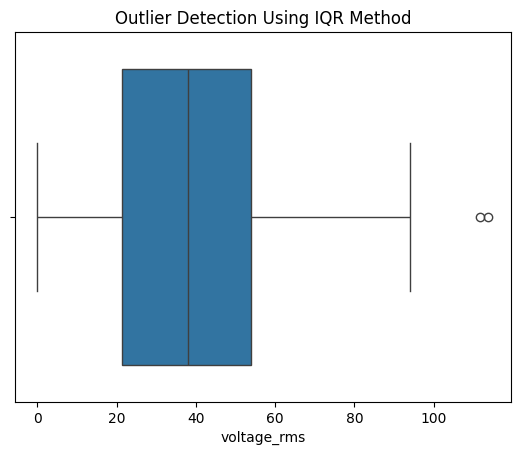

In [ ]:
sns.boxplot(x=df["voltage_rms"])
plt.title("Outlier Detection Using IQR Method")
plt.savefig("outliers.png", dpi=300)

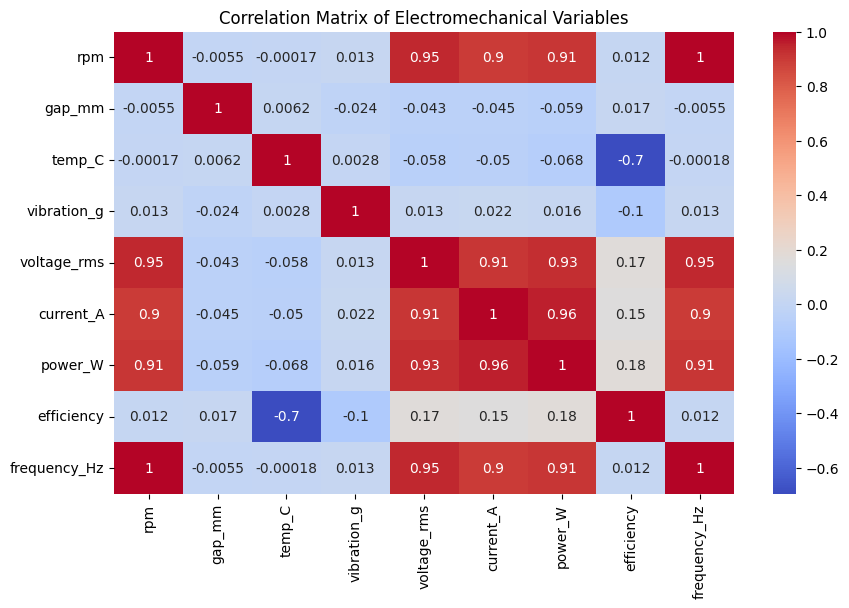

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Electromechanical Variables")
plt.savefig("correlation.png", dpi=300)